# Extended Wigner's friend scenario (with random GHZ friend)

In [20]:
from typing import Optional
import itertools
import functools
import random
import numpy as np
import math
import matplotlib.pyplot as plt

from collections import defaultdict
from enum import Enum
from mitiq import zne

import qiskit
from qiskit_aer.noise import NoiseModel, depolarizing_error, amplitude_damping_error
from qiskit.providers import Backend
from qiskit.providers import fake_provider
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

In [21]:
def extract_values_from_list_of_dicts(key, list_of_dicts):
    return [d[key][0] for d in list_of_dicts if key in d]

## Configurational settings

In [22]:
class Setting(Enum):
    PEEK = 1
    REVERSE_1 = 2
    REVERSE_2 = 3
    
class Observer(Enum):
    ALICE = 0
    BOB = 1

In [23]:
# Experiment settings (peek, reverse_1, and reverse_2).
PEEK = Setting.PEEK.value
REVERSE_1 = Setting.REVERSE_1.value
REVERSE_2 = Setting.REVERSE_2.value
SETTINGS = [PEEK, REVERSE_1, REVERSE_2]

# "Super"-observers (Alice and Bob).
ALICE = Observer.ALICE.value
BOB = Observer.BOB.value
OBSERVERS = [ALICE, BOB]

# Angles and beta term used for Alice and Bob measurement operators from arXiv:1907.05607.
# Note that despite the fact that degrees are used, we need to convert this to radians.
ANGLES = {PEEK: np.deg2rad(168), REVERSE_1: np.deg2rad(0), REVERSE_2: np.deg2rad(118)}
BETA = np.deg2rad(175)

## EWFS circuit

In [24]:
def prepare_bipartite_system(qc: QuantumCircuit):
    """Generates the state: 1/sqrt(2) * (|01> - |10>)"""
    qc.x(ALICE)
    qc.x(BOB)
    qc.h(ALICE)
    qc.cx(ALICE, BOB)


def cnot_ladder(qc: QuantumCircuit, observer: Observer, friend_qubit: int, friend_size: int):
    """CNOT ladder circuit (GHZ without Hadamard)."""
    for i in range(friend_size):
        qc.cx(observer, friend_qubit + i)


def ewfs_rotation(qc: QuantumCircuit, qubit: int, angle: float):
    qc.rz(-angle, qubit)
    qc.h(qubit)
    

def apply_setting(
    qc: QuantumCircuit,
    observer: Observer,
    setting: Setting,
    angle: float,
    friend_qubits: list[int],
    friend_size: int,
):
    """Apply either the PEEK or REVERSE_1/REVERSE_2 settings."""
    if setting is PEEK:
        # Ask friend for the outcome. We pick a random qubit from friend's register.
        random_offset = random.randint(0, friend_size - 1)
        qc.measure(friend_qubits[0] + random_offset, observer)

    elif setting in [REVERSE_1, REVERSE_2]:
        cnot_ladder(qc, observer, friend_qubits[0], friend_size)

        # For either REVERSE_1 or REVERSE_2, apply the appropriate angle rotations.
        # Note that in this case, the rotation should occur on the observer's qubit.
        if observer is ALICE:
            qc.h(ALICE)
            qc.rz(ANGLES[1], ALICE)        

        if observer is BOB:
            qc.h(BOB)        
            qc.rz((BETA - ANGLES[1]), BOB)
        ewfs_rotation(qc, observer, angle)            
        qc.measure(observer, observer)
        

def ewfs(
    alice_setting: Setting,
    bob_setting: Setting,
    angles: list[float],
    beta: float,
    charlie_size: int,
    debbie_size: int,
) -> QuantumCircuit:
    """Generate the circuit for extended Wigner's friend scenario."""
    alice_size, bob_size = 1, 1
    sys_size = alice_size + bob_size
    
    # Qubit sizes for friends.
    charlie_qubits = range(sys_size, (sys_size + charlie_size))
    debbie_qubits = range(sys_size + charlie_size, sys_size + (charlie_size + debbie_size))
        
    # Define quantum registers
    alice, bob, charlie, debbie = [
        QuantumRegister(size, name=name) 
        for size, name in zip([alice_size, bob_size, charlie_size, debbie_size], 
                              ["Alice", "Bob", "Charlie", "Debbie"])
    ]
    measurement = ClassicalRegister(sys_size, name="Measurement")
    
    # Create the Quantum Circuit with the defined registers
    qc = QuantumCircuit(alice, bob, charlie, debbie, measurement)
    
    # Prepare the bipartite quantum system
    prepare_bipartite_system(qc)
    
    # Rotations for measurement.
    ewfs_rotation(qc, ALICE, angles[1])
    ewfs_rotation(qc, BOB, beta - angles[1])

    # Apply the CNOT ladder for Alice-Charlie and Bob-Debbie
    cnot_ladder(qc, ALICE, charlie_qubits[0], charlie_size)
    cnot_ladder(qc, BOB, debbie_qubits[0], debbie_size)
    
    # Applie settings for Alice (and friend Charlie) and Bob (and friend Debbie).
    apply_setting(qc, ALICE, alice_setting, angles[alice_setting], charlie_qubits, charlie_size)
    apply_setting(qc, BOB, bob_setting, (beta - angles[bob_setting]), debbie_qubits, debbie_size)

    return qc

## Expectation values

In [25]:
def single_expect(observer: Observer, setting: Setting, results: dict) -> dict[str, float]:
    """Compute single expectation values for either Alice or Bob."""
    if observer is ALICE:
        ret = 0
        for settings in results.keys():
            if settings[ALICE] is setting:
                probs = results[settings]
                # <A> = P(00) + P(01) - P(10) - P(11)
                ret += (
                    probs.get("00", 0)
                    + probs.get("01", 0)
                    - probs.get("10", 0)
                    - probs.get("11", 0)
                )
        return ret / len(SETTINGS)
    else:
        ret = 0
        for settings in results.keys():
            if settings[BOB] is setting:
                probs = results[settings]
                # <B> = P(00) - P(01) + P(10) - P(11)
                ret += (
                    probs.get("00", 0)
                    - probs.get("01", 0)
                    + probs.get("10", 0)
                    - probs.get("11", 0)
                )
        return ret / len(SETTINGS)

In [26]:
def double_expect(settings: list[Setting], results: dict) -> float:
    """Expectation value of product of two operators."""
    probs = results[settings]
    # <AB> = P(00) - P(01) - P(10) + P(11)
    return (
        probs.get("00", 0) 
        - probs.get("01", 0) 
        - probs.get("10", 0) 
        + probs.get("11", 0)
    )    

## Noise models

In [27]:
def amplitude_damping_noise_model(prob_1: float = 0.04, prob_2: float = 0.08) -> NoiseModel:
    """Defines an amplitude damping noise model with one-qubit and two-qubit errors.
    
    Args:
        prob_1: One-qubit gate error rate (default 4%).
        prob_2: Two-qubit gate error rate (default 8%).
    Returns:
        Amplitude damping noise model.
    """
    # Quantum errors
    error_1 = amplitude_damping_error(param_amp=prob_1, excited_state_population=1)

    error_2 = amplitude_damping_error(param_amp=prob_2, excited_state_population=1)
    error_2 = error_2.tensor(error_2)

    # Add errors to noise model
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(error_1, ["u1", "u2", "u3"])
    noise_model.add_all_qubit_quantum_error(error_2, ["cx"])
    
    return noise_model

In [28]:
def depolarizing_noise_model(error: float = 0.01) -> NoiseModel:
    """Defines an depolarizing noise model with one-qubit.
    
    Args:
        error: One-qubit gate error rate (default 1%).
    Returns:
        Depolarizing noise model.
    """
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error, 1), ["u1", "u2", "u3"])    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error, 2), "cx")
    return noise_model    

## Experiments

In [29]:
def execute(    
    circuit: QuantumCircuit,
    backend: Backend,
    noise_model: NoiseModel,
    shots: float,
    bitstring: str,
):
    job = qiskit.execute(
        experiments=circuit,
        backend=backend,
        noise_model=noise_model,
        basis_gates=noise_model.basis_gates if noise_model is not None else None,
        optimization_level=0,  # Important to preserve folded gates.        
        shots=shots,
    )
    counts = job.result().get_counts()
    probabilities = {key[::-1]: value / shots for key, value in counts.items()}
    print(probabilities)
    return probabilities[bitstring]

In [30]:
def generate_all_experiments(
    backend: Backend,
    noise_model: NoiseModel,
    shots: float,
    angles: list[float],
    beta: float,
    charlie_size: int,
    debbie_size: int,
    use_zne: bool = False
) -> dict[tuple[Observer, Observer], list[float]]:
    """Generate probabilities for all combinations of experimental settings."""
    all_experiment_combos = list(itertools.product(SETTINGS, repeat=2))
    
    results = {}
    #state_vectors = {}
    for alice_setting, bob_setting in all_experiment_combos:
        ewfs_circuit = ewfs(
            alice_setting=alice_setting,
            bob_setting=bob_setting, 
            angles=angles,
            beta=beta,
            charlie_size=charlie_size,
            debbie_size=debbie_size
        )
        if use_zne:
            result = {} 
            for bitstring in ["00", "01", "10", "11"]:
                executor = functools.partial(
                    execute, backend=backend, noise_model=noise_model, shots=shots, bitstring=bitstring
                )
                result[bitstring] = zne.execute_with_zne(ewfs_circuit, executor)
            results[(alice_setting, bob_setting)] = result
            
        else:
            job = qiskit.execute(
                experiments=ewfs_circuit,
                backend=backend,
                noise_model=noise_model,
                basis_gates=noise_model.basis_gates if noise_model is not None else None,
                #optimization_level=0,  # Important to preserve folded gates.        
                shots=shots,
            )
            counts = job.result().get_counts()
            #state_vectors[(alice_setting, bob_setting)] = job.result().get_statevector(ewfs_circuit)
            
            results[(alice_setting, bob_setting)] = {key[::-1]: value / shots for key, value in counts.items()}            
    return results#, state_vectors

In [31]:
def compute_inequalities(results: dict, verbose: bool = False) -> dict[str, float]:
    A1 = single_expect(ALICE, PEEK, results)
    B1 = single_expect(BOB, PEEK, results)

    A2 = single_expect(ALICE, REVERSE_1, results)
    B2 = single_expect(BOB, REVERSE_1, results)

    A1B1 = double_expect((PEEK, PEEK), results)
    A1B2 = double_expect((PEEK, REVERSE_1), results)
    A1B3 = double_expect((PEEK, REVERSE_2), results)

    A2B1 = double_expect((REVERSE_1, PEEK), results)
    A2B2 = double_expect((REVERSE_1, REVERSE_1), results)
    A2B3 = double_expect((REVERSE_1, REVERSE_2), results)

    A3B1 = double_expect((REVERSE_2, PEEK), results)
    A3B2 = double_expect((REVERSE_2, REVERSE_1), results)
    A3B3 = double_expect((REVERSE_2, REVERSE_2), results)
    
    # Local-friendliness inequalities:
    # Eq. (13) from [1].
    lf = -A1 - A2 - B1 - B2 - A1B1 - 2*A1B2 - 2*A2B1 + 2*A2B2 - A2B3 - A3B2 - A3B3 - 6
    # Eq. (15) from [1].
    I3322 = -A1 + A2 + B1 - B2 + A1B1 - A1B2 - A1B3 - A2B1 + A2B2 - A2B3 - A3B1 - A3B2 - 4 

    # Brukner inequalities:
    # Eq. (17) from [1].
    brukner = A1B1 - A1B3 - A2B1 - A2B3 - 2
    # Eq. (18) from [1].
    semi_brukner = -A1B2 + A1B3 - A3B2 - A3B3 - 2

    # Bell non-LF 
    # Eq. (22) from [1].
    bell_non_lf = A2B2 - A2B3 - A3B2 - A3B3 - 2
    
    if verbose:
        print("******Inequalities******")
        print(f"{semi_brukner=} -- is violated: {semi_brukner > 0}")
        print(f"{brukner=} -- is violated: {brukner > 0}")
        print(f"{lf=} -- is violated: {lf > 0}")
        print(f"{I3322=} -- is_violated: {I3322 > 0}")
        print(f"{bell_non_lf=} -- is_violated: {bell_non_lf > 0}")
        print("**************************")
        
    return {
        "lf": lf,
        "I3322": I3322,
        "brukner": brukner,
        "semi_brukner": semi_brukner,
        "bell_non_lf": bell_non_lf,
    }

### EWFS circuit

/Users/vrusso/Projects/research/wigners_friend/venv/lib/python3.11/site-packages/qiskit/visualization/circuit/matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


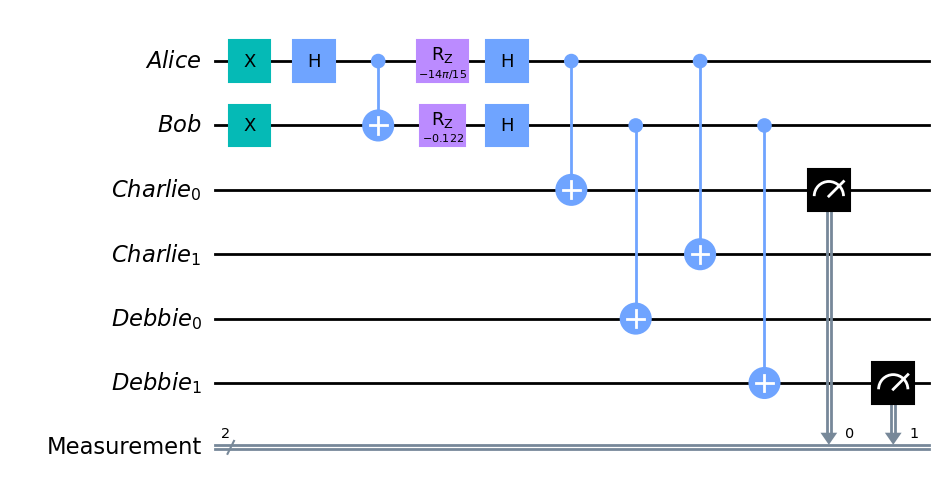

In [32]:
qc = ewfs(PEEK, PEEK, ANGLES, BETA, charlie_size=2, debbie_size=2)
qc.draw("mpl")#.savefig("ewfs_peek_peek.pdf")
#print(qc.draw("latex_source"))

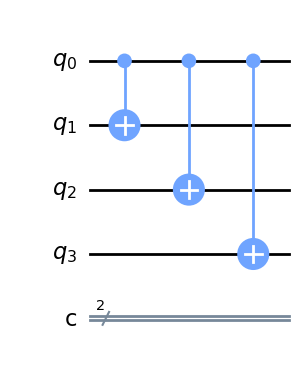

In [33]:
circuit = QuantumCircuit(4, 2)
cnot_ladder(circuit, 0, 1, 3)
circuit.draw("mpl")

## Experiments

In [39]:
def run_experiment(
    backend: Backend,
    noise_model: NoiseModel,
    friend_sizes: list[int],
    shots: float,
    use_zne: bool = False,
    verbose: bool = True,
    num_trials: int = 1
):
    all_results = {
        fs: {inequality: [] for inequality in ["lf", "I3322", "brukner", "semi_brukner", "bell_non_lf"]}
        for fs in friend_sizes
    }
    #all_state_vectors = []

    for friend_size in friend_sizes:
        for _ in range(num_trials):
            #results, state_vectors = generate_all_experiments(
            results = generate_all_experiments(            
                backend=backend,
                noise_model=noise_model,
                shots=shots,
                angles=ANGLES,
                beta=BETA,
                charlie_size=friend_size,
                debbie_size=friend_size,
                use_zne=use_zne,
            )
            violations = compute_inequalities(results, verbose=verbose)
            #all_state_vectors.append(state_vectors)
            for key in violations:
                all_results[friend_size][key].append(violations[key])

    return all_results#, all_state_vectors

## Plotting

In [40]:
def plot_results(
    ax,
    results: dict, 
    friend_sizes: list[int], 
    plot_title: str,
    plot_error_bars: bool = False, 
):
    # Compute averages and standard deviations
    avg_results = {}
    std_results = {}
    for fs in results:
        avg_results[fs] = {}
        std_results[fs] = {}
        for key in results[fs]:
            avg_results[fs][key] = np.mean(results[fs][key])
            if plot_error_bars:
                std_results[fs][key] = np.std(results[fs][key])

    # Plotting    
    markers = ["o", "s", "^", "*", "H"]
    colors = ["tab:green", "tab:orange", "tab:pink", "tab:blue", "tab:purple"]
    titles = ["LF", "I3322", "Brukner", "Semi-Brukner", "Bell non-LF"]

    for i, key in enumerate(["lf", "I3322", "brukner", "semi_brukner", "bell_non_lf"]):
        means = [np.mean(results[fs][key]) for fs in friend_sizes]
        errors = [np.std(results[fs][key]) for fs in friend_sizes] if plot_error_bars else None
        ax.errorbar(friend_sizes, means, yerr=errors, label=titles[i], fmt=markers[i], color=colors[i], capsize=5)

    ax.axhline(0, color="red", linestyle="dashed")
    ax.set_xticks(friend_sizes)
    ax.set_title(plot_title)
    ax.grid(True)

## Hardware

In [41]:
from qiskit_ibm_runtime import QiskitRuntimeService

IBM_PROVIDER_TOKEN="f93ccee55d555d956b5bd12641edb2b79f29c28235f064dccb3cfba3109d144271ce5a31fa05b26430abe31be8e87cf50f542cdf84abe3473c2f58fa7a1f56c5"

# Save an IBM Quantum account and set it as your default account.
QiskitRuntimeService.save_account(channel="ibm_quantum", token=IBM_PROVIDER_TOKEN, set_as_default=True, overwrite=True)

# Load saved credentials
service = QiskitRuntimeService()

In [42]:
# Parameters for all plots
friend_sizes = range(1, 7)
num_trials = 1
shots = 10_000

# Fake Hanoi
backend = fake_provider.FakeHanoiV2()
noise_model = NoiseModel.from_backend(backend)
fake_hanoi_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=False,
)

# Hanoi hardware data
backend = service.backend("ibm_hanoi")
noise_model = NoiseModel.from_backend(backend)
hanoi_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
)

ERROR - ping/pong timed out - goodbye
IOStream.flush timed out
runtime_job._start_websocket_client:WARNING:2024-01-19 19:11:40,498: An error occurred while streaming results from the server for job cpnac089nad0008prf20:
Traceback (most recent call last):
  File "/Users/vrusso/Projects/research/wigners_friend/venv/lib/python3.11/site-packages/qiskit_ibm_runtime/runtime_job.py", line 531, in _start_websocket_client
    self._ws_client.job_results()
  File "/Users/vrusso/Projects/research/wigners_friend/venv/lib/python3.11/site-packages/qiskit_ibm_provider/api/clients/runtime_ws.py", line 70, in job_results
    self.stream(url=url, retries=max_retries, backoff_factor=backoff_factor)
  File "/Users/vrusso/Projects/research/wigners_friend/venv/lib/python3.11/site-packages/qiskit_ibm_provider/api/clients/base.py", line 230, in stream
    raise WebsocketError(error_message)
qiskit_ibm_provider.api.exceptions.WebsocketError: 'Max retries exceeded: Failed to establish a websocket connection. Er

******Inequalities******
semi_brukner=0.2030000000000003 -- is violated: True
brukner=-0.42779999999999996 -- is violated: False
lf=0.11699999999999999 -- is violated: True
I3322=-0.27233333333333265 -- is_violated: False
bell_non_lf=0.29620000000000024 -- is_violated: True
**************************
******Inequalities******
semi_brukner=-0.5002000000000002 -- is violated: False
brukner=-0.3787999999999998 -- is violated: False
lf=-1.2691999999999997 -- is violated: False
I3322=-0.7334 -- is_violated: False
bell_non_lf=-0.43179999999999996 -- is_violated: False
**************************
******Inequalities******
semi_brukner=-1.0928 -- is violated: False
brukner=-1.0008000000000001 -- is violated: False
lf=-3.321200000000001 -- is violated: False
I3322=-1.9468666666666672 -- is_violated: False
bell_non_lf=-1.3262 -- is_violated: False
**************************
******Inequalities******
semi_brukner=-1.0478 -- is violated: False
brukner=-1.6918000000000002 -- is violated: False
lf=-3.62

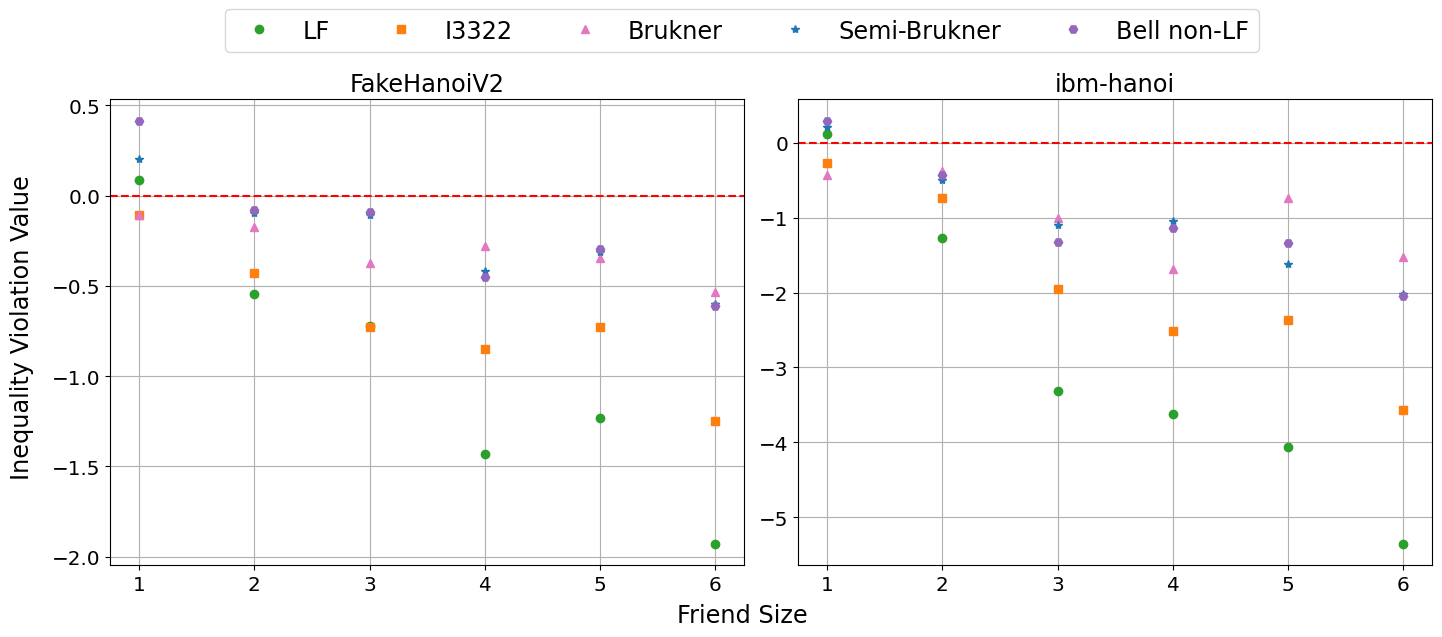

In [46]:
fig, axs = plt.subplots(1,2, figsize=(15, 6))  # Create a figure with two subplots

plot_results(axs[0], fake_hanoi_results, friend_sizes, plot_error_bars=False, plot_title="FakeHanoiV2")
plot_results(axs[1], hanoi_results, friend_sizes, plot_error_bars=False, plot_title="ibm-hanoi")

# Use the legend from the first subplot
handles, labels = axs[0].get_legend_handles_labels()

# Create a single shared legend
fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.05), fontsize="xx-large")

# Set common x-axis and y-axis labels
fig.text(0.5, 0.02, "Friend Size", ha="center", va="center", fontsize="xx-large")
fig.text(0.02, 0.5, "Inequality Violation Value", ha="center", va="center", rotation="vertical", fontsize="xx-large")

for ax in np.ravel(axs):
    ax.set_title(ax.get_title(), fontsize="xx-large")
    ax.tick_params(axis="x", labelsize="x-large")
    ax.tick_params(axis="y", labelsize="x-large")    

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.savefig("ghz_hanoi_hardware.pdf", bbox_inches="tight")
plt.show()

In [47]:
# Parameters for all plots
friend_sizes = range(1, 7)
num_trials = 1
shots = 10_000

# Fake Kolkata
backend = fake_provider.FakeKolkataV2()
noise_model = NoiseModel.from_backend(backend)
fake_kolkata_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=False,
)

# Kolkata hardware data
backend = service.backend("ibmq_kolkata")
noise_model = NoiseModel.from_backend(backend)
kolkata_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
)

******Inequalities******
semi_brukner=-0.013199999999999878 -- is violated: False
brukner=0.033399999999999874 -- is violated: True
lf=-0.03573333333333384 -- is violated: False
I3322=0.10126666666666662 -- is_violated: True
bell_non_lf=0.4129999999999998 -- is_violated: True
**************************
******Inequalities******
semi_brukner=-0.577 -- is violated: False
brukner=-1.0382000000000002 -- is violated: False
lf=-2.0584000000000002 -- is violated: False
I3322=-1.6962666666666673 -- is_violated: False
bell_non_lf=-0.7970000000000002 -- is_violated: False
**************************
******Inequalities******
semi_brukner=-1.6522000000000001 -- is violated: False
brukner=-1.0052 -- is violated: False
lf=-3.6841333333333335 -- is violated: False
I3322=-2.2480666666666664 -- is_violated: False
bell_non_lf=-1.5500000000000003 -- is_violated: False
**************************
******Inequalities******
semi_brukner=-1.6448 -- is violated: False
brukner=-1.0734 -- is violated: False
lf=-4.7

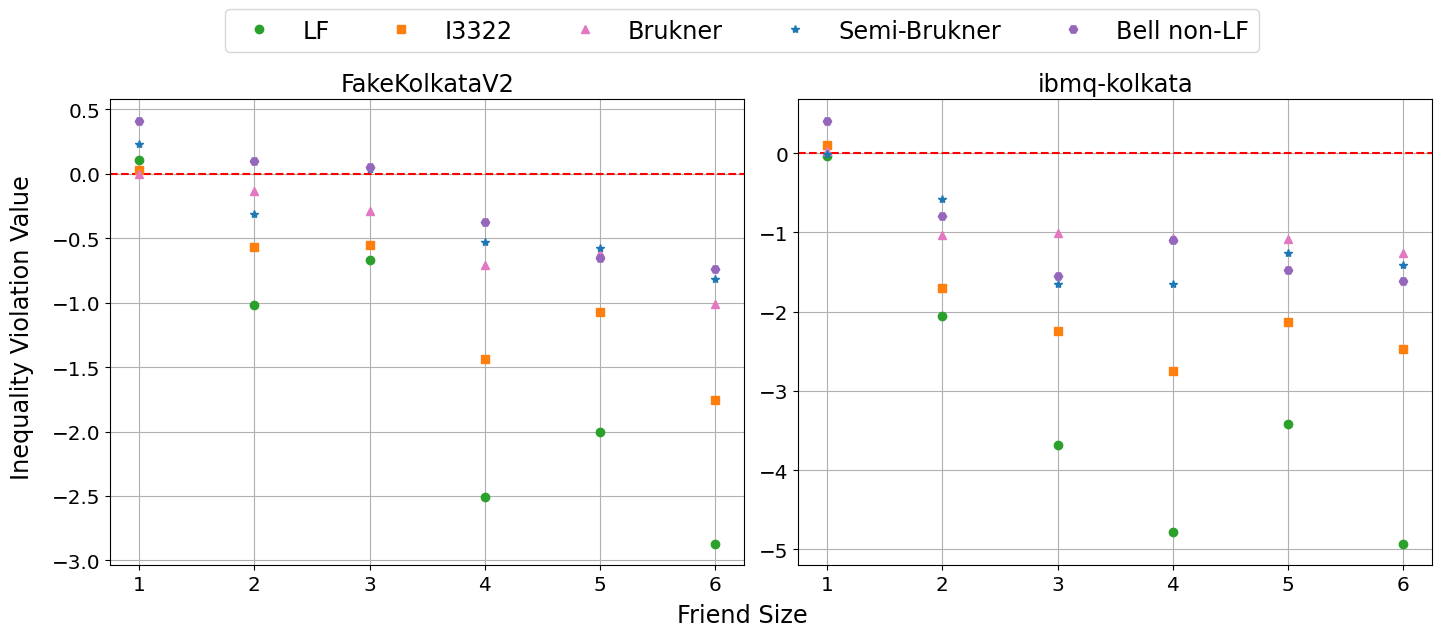

In [48]:
fig, axs = plt.subplots(1,2, figsize=(15, 6))  # Create a figure with two subplots

plot_results(axs[0], fake_kolkata_results, friend_sizes, plot_error_bars=False, plot_title="FakeKolkataV2")
plot_results(axs[1], kolkata_results, friend_sizes, plot_error_bars=False, plot_title="ibmq-kolkata")

# Use the legend from the first subplot
handles, labels = axs[0].get_legend_handles_labels()

# Create a single shared legend
fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.05), fontsize="xx-large")

# Set common x-axis and y-axis labels
fig.text(0.5, 0.02, "Friend Size", ha="center", va="center", fontsize="xx-large")
fig.text(0.02, 0.5, "Inequality Violation Value", ha="center", va="center", rotation="vertical", fontsize="xx-large")

for ax in np.ravel(axs):
    ax.set_title(ax.get_title(), fontsize="xx-large")
    ax.tick_params(axis="x", labelsize="x-large")
    ax.tick_params(axis="y", labelsize="x-large")    

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.savefig("ghz_kolkata_hardware.pdf", bbox_inches="tight")
plt.show()

In [50]:
# Parameters for all plots
friend_sizes = range(1, 7)
num_trials = 1
shots = 10_000

# Fake Cairo
backend = fake_provider.FakeCairoV2()
noise_model = NoiseModel.from_backend(backend)
fake_cairo_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=False,
)

# Cairo hardware data
backend = service.backend("ibm_cairo")
noise_model = NoiseModel.from_backend(backend)
cairo_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
)

ERROR - Connection to remote host was lost. - goodbye
ERROR - Connection to remote host was lost. - goodbye


******Inequalities******
semi_brukner=0.16720000000000024 -- is violated: True
brukner=-0.09539999999999971 -- is violated: False
lf=0.02346666666666586 -- is violated: True
I3322=-0.08959999999999946 -- is_violated: False
bell_non_lf=0.38859999999999983 -- is_violated: True
**************************
******Inequalities******
semi_brukner=-0.18340000000000023 -- is violated: False
brukner=-1.0701999999999998 -- is violated: False
lf=-1.232733333333334 -- is violated: False
I3322=-1.3978000000000002 -- is_violated: False
bell_non_lf=-0.32479999999999976 -- is_violated: False
**************************
******Inequalities******
semi_brukner=-0.8213999999999997 -- is violated: False
brukner=-0.6459999999999999 -- is violated: False
lf=-2.499 -- is violated: False
I3322=-1.4463999999999997 -- is_violated: False
bell_non_lf=-0.9463999999999997 -- is_violated: False
**************************
******Inequalities******
semi_brukner=-1.5030000000000001 -- is violated: False
brukner=-0.6356000000

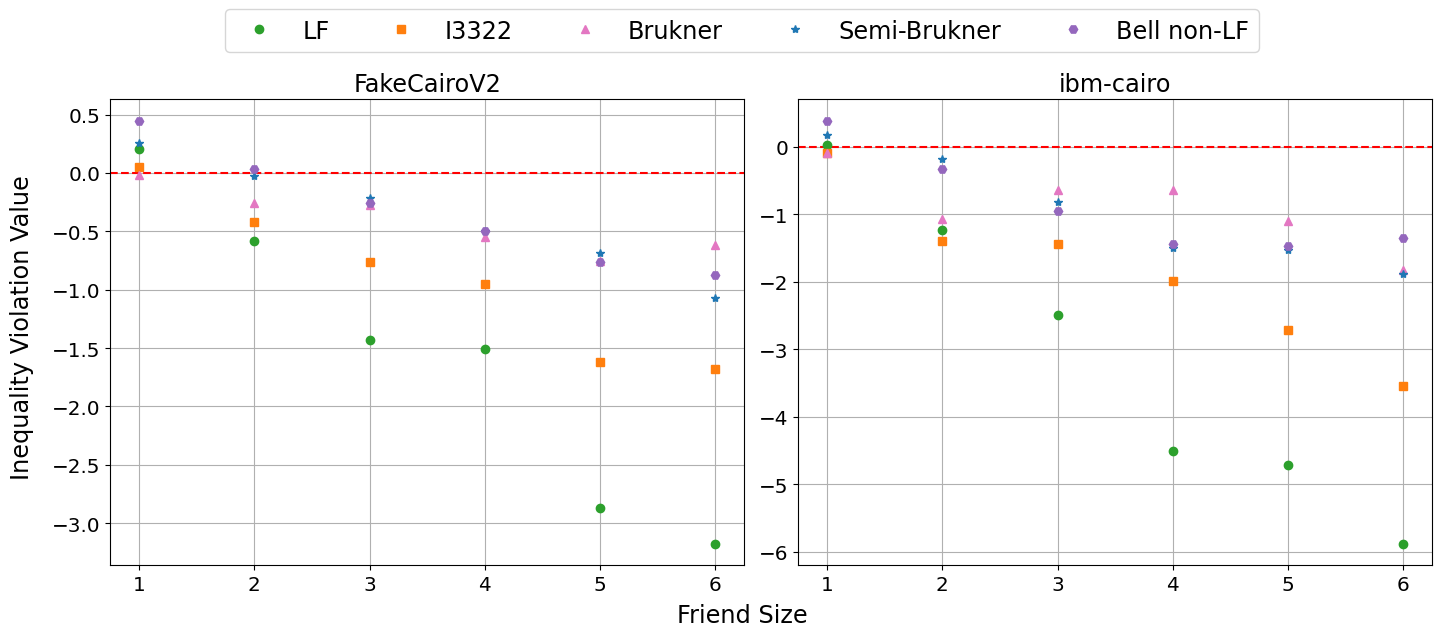

In [54]:
fig, axs = plt.subplots(1,2, figsize=(15, 6))

plot_results(axs[0], fake_cairo_results, friend_sizes, plot_error_bars=False, plot_title="FakeCairoV2")
plot_results(axs[1], cairo_results, friend_sizes, plot_error_bars=False, plot_title="ibm-cairo")

# Use the legend from the first subplot
handles, labels = axs[0].get_legend_handles_labels()

# Create a single shared legend
fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.05), fontsize="xx-large")

# Set common x-axis and y-axis labels
fig.text(0.5, 0.02, "Friend Size", ha="center", va="center", fontsize="xx-large")
fig.text(0.02, 0.5, "Inequality Violation Value", ha="center", va="center", rotation="vertical", fontsize="xx-large")

for ax in np.ravel(axs):
    ax.set_title(ax.get_title(), fontsize="xx-large")
    ax.tick_params(axis="x", labelsize="x-large")
    ax.tick_params(axis="y", labelsize="x-large")    

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.savefig("ghz_cairo_hardware.pdf", bbox_inches="tight")
plt.show()

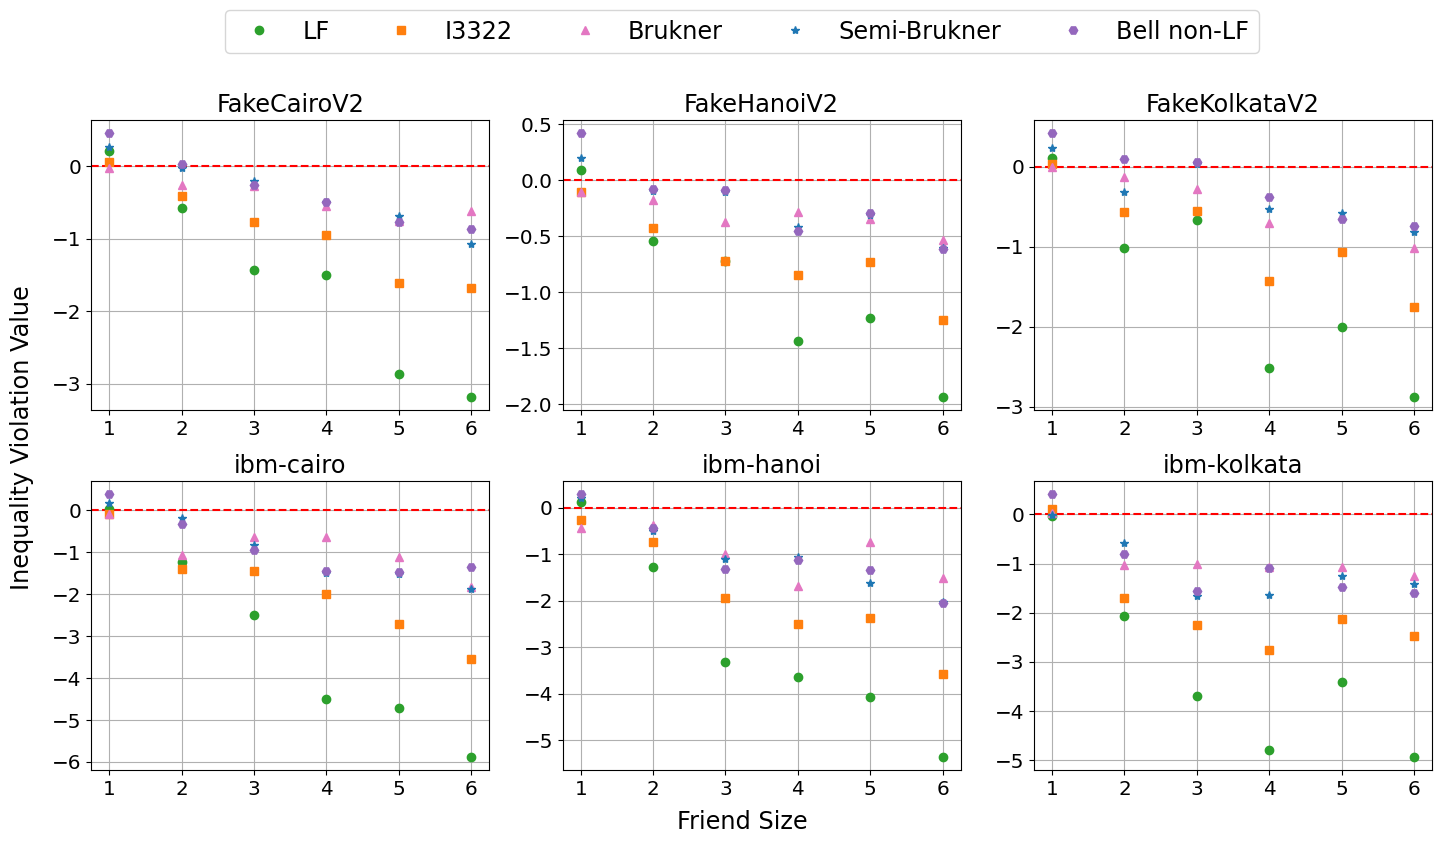

In [56]:
fig, axs = plt.subplots(2,3, figsize=(15, 8))

plot_results(axs[0, 0], fake_cairo_results, friend_sizes, plot_error_bars=False, plot_title="FakeCairoV2")
plot_results(axs[0, 1], fake_hanoi_results, friend_sizes, plot_error_bars=False, plot_title="FakeHanoiV2")
plot_results(axs[0, 2], fake_kolkata_results, friend_sizes, plot_error_bars=False, plot_title="FakeKolkataV2")
plot_results(axs[1, 0], cairo_results, friend_sizes, plot_error_bars=False, plot_title="ibm-cairo")
plot_results(axs[1, 1], hanoi_results, friend_sizes, plot_error_bars=False, plot_title="ibm-hanoi")
plot_results(axs[1, 2], kolkata_results, friend_sizes, plot_error_bars=False, plot_title="ibm-kolkata")

# Use the legend from the first subplot
handles, labels = axs[0,0].get_legend_handles_labels()

# Create a single shared legend
fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.05), fontsize="xx-large")

# Set common x-axis and y-axis labels
fig.text(0.5, 0.02, "Friend Size", ha="center", va="center", fontsize="xx-large")
fig.text(0.02, 0.5, "Inequality Violation Value", ha="center", va="center", rotation="vertical", fontsize="xx-large")

for ax in np.ravel(axs):
    ax.set_title(ax.get_title(), fontsize="xx-large")
    ax.tick_params(axis="x", labelsize="x-large")
    ax.tick_params(axis="y", labelsize="x-large")    

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.savefig("ghz_hardware.pdf", bbox_inches="tight")
plt.show()

### Ideal and noisy simulators over friend size

In [ ]:
# Parameters for all plots
friend_sizes = range(1, 7)
num_trials = 10
shots = 10_000
backend = qiskit.Aer.get_backend("aer_simulator")

# Ideal simulator data
noise_model = None
simulator_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=False,
)

# Depolarizing noise (1%)
noise_model = depolarizing_noise_model(error=0.01)
depolarizing_1perc_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=False,
)

# Depolarizing noise (2%)
noise_model = depolarizing_noise_model(error=0.02)
depolarizing_2perc_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=False,
)

# Depolarizing noise (3%)
noise_model = depolarizing_noise_model(error=0.03)
depolarizing_3perc_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=False,
)

### Depolarizing noise simulator violations

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(15, 12))  # Create a figure with two subplots

plot_results(axs[0,0], simulator_results, friend_sizes, plot_error_bars=True, plot_title="Ideal simulator")
plot_results(axs[0,1], depolarizing_1perc_results, friend_sizes, plot_error_bars=True, plot_title="1% depolarizing noise")
plot_results(axs[1,0], depolarizing_2perc_results, friend_sizes, plot_error_bars=True, plot_title="2% depolarizing noise")
plot_results(axs[1,1], depolarizing_3perc_results, friend_sizes, plot_error_bars=True, plot_title="3% depolarizing noise")

# Use the legend from the first subplot
handles, labels = axs[0,0].get_legend_handles_labels()

# Create a single shared legend
fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.05), fontsize="xx-large")

# Set common x-axis and y-axis labels
fig.text(0.5, 0.02, "Friend Size", ha="center", va="center", fontsize="xx-large")
fig.text(0.02, 0.5, "Inequality Violation Value", ha="center", va="center", rotation="vertical", fontsize="xx-large")

for ax in np.ravel(axs):
    ax.set_title(ax.get_title(), fontsize="xx-large")    
    ax.tick_params(axis="x", labelsize="x-large")
    ax.tick_params(axis="y", labelsize="x-large")

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.savefig("ghz_noise_levels_vs_friend_sizes.pdf", bbox_inches="tight")
plt.show()

## Amplitude damping noise simulator violations

In [ ]:
# Parameters for all plots
friend_sizes = range(1, 6)
num_trials = 10
shots = 10_000
backend = qiskit.Aer.get_backend("aer_simulator")

# Amplitude damping (1%)
noise_model = amplitude_damping_noise_model(prob_1=0.01, prob_2=0.00)
amplitude_damping_1perc_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=False,
)

# Amplitude damping noise (2%)
noise_model = amplitude_damping_noise_model(prob_1=0.02, prob_2=0.00)
amplitude_damping_2perc_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=False,
)

# Amplitude damping noise (3%)
noise_model = amplitude_damping_noise_model(prob_1=0.03, prob_2=0.00)
amplitude_damping_3perc_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=False,
)

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(15, 6))  # Create a figure with two subplots

plot_results(axs[0], amplitude_damping_1perc_results, friend_sizes, plot_error_bars=True, plot_title="1% amplitude damping noise")
plot_results(axs[1], amplitude_damping_2perc_results, friend_sizes, plot_error_bars=True, plot_title="2% amplitude damping noise")
plot_results(axs[2], amplitude_damping_3perc_results, friend_sizes, plot_error_bars=True, plot_title="3% amplitude damping noise")

# Use the legend from the first subplot
handles, labels = axs[0].get_legend_handles_labels()

# Create a single shared legend
fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.05), fontsize="xx-large")

# Set common x-axis and y-axis labels
fig.text(0.5, 0.02, "Friend Size", ha="center", va="center", fontsize="xx-large")
fig.text(0.02, 0.5, "Inequality Violation Value", ha="center", va="center", rotation="vertical", fontsize="xx-large")

for ax in np.ravel(axs):
    ax.set_title(ax.get_title(), fontsize="xx-large")
    ax.tick_params(axis="x", labelsize="x-large")
    ax.tick_params(axis="y", labelsize="x-large")    

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.savefig("ghz_ampltiude_damping_vs_friend_sizes.pdf", bbox_inches="tight")
plt.show()

## Fake device plotting

In [ ]:
friend_sizes = range(1, 4)
num_trials = 1
shots = 10_000

# Fake Kolkata
backend = fake_provider.FakeKolkataV2()
noise_model = NoiseModel.from_backend(backend)
fake_kolkata_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=False,
)

# Fake Sherbrooke
backend = fake_provider.FakeSherbrooke()
noise_model = NoiseModel.from_backend(backend)
fake_sherbrooke_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=False,
)

# Fake Hanoi
backend = fake_provider.FakeHanoiV2()
noise_model = NoiseModel.from_backend(backend)
fake_hanoi_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=False,
)

# Fake Cairo
backend = fake_provider.FakeCairoV2()
noise_model = NoiseModel.from_backend(backend)
fake_cairo_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=False,
)

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(15, 12))  # Create a figure with two subplots

plot_results(axs[0,0], fake_kolkata_results, friend_sizes, plot_error_bars=False, plot_title="Fake KolkataV2")
plot_results(axs[0,1], fake_sherbrooke_results, friend_sizes, plot_error_bars=False, plot_title="Fake Sherbrooke")
plot_results(axs[1,0], fake_hanoi_results, friend_sizes, plot_error_bars=False, plot_title="Fake HanoiV2")
plot_results(axs[1,1], fake_cairo_results, friend_sizes, plot_error_bars=False, plot_title="Fake CairoV2")

# Use the legend from the first subplot
handles, labels = axs[0,0].get_legend_handles_labels()

# Create a single shared legend
fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.05), fontsize="xx-large")

# Set common x-axis and y-axis labels
fig.text(0.5, 0.02, "Friend Size", ha="center", va="center", fontsize="xx-large")
fig.text(0.02, 0.5, "Inequality Violation Value", ha="center", va="center", rotation="vertical", fontsize="xx-large")

for ax in np.ravel(axs):
    ax.set_title(ax.get_title(), fontsize="xx-large")
    ax.tick_params(axis="x", labelsize="x-large")
    ax.tick_params(axis="y", labelsize="x-large")    

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.savefig("ghz_noise_levels_vs_friend_sizes_fake_devices.pdf", bbox_inches="tight")
plt.show()

## Scratch pad / Experimental notebook code

Below here is code that is under 👷‍♂️

🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧🚧

In [ ]:
from qiskit.quantum_info import state_fidelity

# Parameters for all plots
friend_sizes = range(1, 6)
num_trials = 1
shots = 1000
backend = qiskit.Aer.get_backend("statevector_simulator")

# Ideal simulator data
noise_model = None
simulator_results, simulator_state_vectors = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=False,
)

# Depolarizing noise (1%)
noise_model = depolarizing_noise_model(error=0.00)
depolarizing_1perc_results, depolarizing_1perc_state_vectors = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=False,
)

# for i in range(len(depolarizing_1perc_state_vectors)):
#     state_fidelity(simulator_state_vectors[i], depolarizing_1perc_state_vectors[i])

In [ ]:
for i in range(len(depolarizing_1perc_state_vectors)):
    print(f"Friend size: {i}")
    for k in simulator_state_vectors[i].keys(): 
        print(k, state_fidelity(simulator_state_vectors[i][k], depolarizing_1perc_state_vectors[i][k]))

### Noise vs. friend size violations

In [ ]:
def data_noise_levels_per_friend_size(
    noise_levels: list[float], 
    friend_sizes: list[int], 
    shots: int
):
    """Data for noise_levels over friend_sizes."""
    plot_results = defaultdict(lambda: defaultdict(list))
    for friend_size in friend_sizes:
        for noise_level in noise_levels:
            print(f"{friend_size=}, {noise_level=}")

            noise_model = NoiseModel()
            noise_model.add_all_qubit_quantum_error(depolarizing_error(noise_level, 1), ["u1", "u2", "u3"])
            result = run_experiment(
                backend=qiskit.Aer.get_backend("aer_simulator"),
                noise_model=noise_model,
                friend_size=friend_size,
                shots=shots,
                verbose=False
            )
            for key in result:
                plot_results[friend_size][key].append(result[key][0])
    return plot_results

In [ ]:
friend_sizes = range(1, 7)
noise_levels = np.linspace(0, 0.05, 6)
shots = 10_000

plot_data = data_noise_levels_per_friend_size(
    noise_levels=noise_levels, 
    friend_sizes=friend_sizes, 
    shots=shots,
)

In [ ]:
def plot_noise_levels_per_friend_size(
    plot_data,
    noise_levels: list[float], 
    friend_sizes: list[int],
    plot_file_name,
):    
    """Plot how EWFS behaves across noise levels for set of friend sizes."""
    plot_attrs = {
        "lf": {"marker": "o", "color": "tab:green", "title": "LF"},
        "I3322": {"marker": "s", "color": "tab:orange", "title": "I3322"},
        "brukner": {"marker": "^", "color": "tab:pink", "title": "Brukner"},
        "semi_brukner": {"marker": "*", "color": "tab:blue", "title": "Semi-Brukner"},
        "bell_non_lf": {"marker": "H", "color": "tab:purple", "title": "Bell non-LF"}
    }

    # Set the number of columns to 2 and calculate the number of rows needed
    num_cols = 3
    num_rows = math.ceil(len(friend_sizes) / num_cols)

    # Create the subplots in a 2-column grid
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 5 * num_rows))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    # Iterate over each friend size and plot
    for i, friend_size in enumerate(friend_sizes):
        ax = axes[i]
        for key, settings in plot_attrs.items():
            ax.plot(
                noise_levels, plot_data[friend_size][key], label=settings["title"],
                marker=settings["marker"], color=settings["color"]
            )
        ax.axhline(0, color="red", linestyle="dotted")
        ax.set_title(f"Friend size {friend_size}")
        ax.legend()

    # Hide any unused axes
    for i in range(len(friend_sizes), len(axes)):
        axes[i].axis('off')

    # Set shared x-label and y-label for the entire figure
    fig.text(0.5, 0.04, "Noise Level", ha="center", va="center", fontsize=12)
    fig.text(0.04, 0.5, "Value", ha="center", va="center", rotation="vertical", fontsize=12)

    plt.tight_layout(rect=[0.07, 0.08, 1, 0.95])
    plt.savefig(plot_file_name, bbox_inches="tight")
    plt.show()

In [ ]:
plot_noise_levels_per_friend_size(
    plot_data=plot_data, 
    noise_levels=noise_levels, 
    friend_sizes=friend_sizes, 
    plot_file_name="ghz_noise_levels_vs_friend_sizes.pdf"
)

### Friend size vs. noise violations

In [ ]:
def data_friend_size_per_noise_level(
    noise_levels: list[float], 
    friend_sizes: list[int], 
    shots: int
):
    """Data for friend_sizes over noise_levels."""
    plot_results = defaultdict(lambda: defaultdict(list))
    for noise_level in noise_levels:
        noise_model = NoiseModel()
        noise_model.add_all_qubit_quantum_error(depolarizing_error(noise_level, 1), ["u1", "u2", "u3"])        
        for friend_size in friend_sizes:
            print(f"{noise_level=}, {friend_size=}")
            result = run_experiment(
                backend=qiskit.Aer.get_backend("aer_simulator"),
                noise_model=noise_model,
                friend_size=friend_size,
                shots=shots,
                verbose=False
            )
            for key in result:
                plot_results[noise_level][key].append(result[key][0])
    return plot_results

In [ ]:
friend_sizes = range(1, 7)
noise_levels = np.linspace(0, 0.05, 6)
shots = 10_000

plot_data = data_friend_size_per_noise_level(
    noise_levels=noise_levels, 
    friend_sizes=friend_sizes, 
    shots=shots,
)

In [ ]:
def plot_friend_size_per_noise_levels(
    plot_data,
    noise_levels: list[float], 
    friend_sizes: list[int],
    plot_file_name,
):    
    """Plot how EWFS behaves across noise levels for set of friend sizes."""
    plot_attrs = {
        "lf": {"marker": "o", "color": "tab:green", "title": "LF"},
        "I3322": {"marker": "s", "color": "tab:orange", "title": "I3322"},
        "brukner": {"marker": "^", "color": "tab:pink", "title": "Brukner"},
        "semi_brukner": {"marker": "*", "color": "tab:blue", "title": "Semi-Brukner"},
        "bell_non_lf": {"marker": "H", "color": "tab:purple", "title": "Bell non-LF"}
    }

    # Set the number of columns to 2 and calculate the number of rows needed
    num_cols = 2
    num_rows = math.ceil(len(friend_sizes) / num_cols)

    # Create the subplots in a 2-column grid
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 5 * num_rows))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    # Iterate over each friend size and plot
    for i, noise_level in enumerate(noise_levels):
        ax = axes[i]
        for key, settings in plot_attrs.items():
            ax.plot(
                friend_sizes, plot_data[noise_level][key], label=settings["title"],
                marker=settings["marker"], color=settings["color"]
            )
        ax.axhline(0, color="red", linestyle="dotted")
        ax.set_title(f"Noise level {noise_level}")
        ax.legend()

    # Hide any unused axes
    for i in range(len(noise_levels), len(axes)):
        axes[i].axis('off')

    # Set shared x-label and y-label for the entire figure
    fig.text(0.5, 0.04, "Friend size", ha="center", va="center", fontsize=12)
    fig.text(0.04, 0.5, "Value", ha="center", va="center", rotation="vertical", fontsize=12)

    plt.tight_layout(rect=[0.07, 0.08, 1, 0.95])
    plt.savefig(plot_file_name, bbox_inches="tight")
    plt.show()

In [ ]:
plot_friend_size_per_noise_levels(
    plot_data=plot_data, 
    noise_levels=noise_levels, 
    friend_sizes=friend_sizes, 
    plot_file_name="ghz_friend_sizes_vs_noise_levels.pdf"
)

### Plot grid

In [ ]:
def data_violation_grid(friend_sizes: list[int], shots: int):
    plot_data = {
        "simulator_values": [],
        "depolarizing_values_1": [],        
        "depolarizing_values_5": [],                
    }
    
    print("Running data for simulator...")
    for friend_size in friend_sizes:
        print(f"{friend_size=}")        
        plot_data["simulator_values"].append(
            run_experiment(
                backend=qiskit.Aer.get_backend("aer_simulator"),
                noise_model=None,
                friend_size=friend_size,
                shots=shots,
                verbose=True
            )
        )
        
    print("Running data for 1% depolarizing noise...")
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(0.01, 1), ["u1", "u2", "u3"])
    for friend_size in friend_sizes:
        print(f"{friend_size=}")
        plot_data["depolarizing_values_1"].append(
            run_experiment(
                backend=qiskit.Aer.get_backend("aer_simulator"),
                noise_model=noise_model,
                friend_size=friend_size,
                shots=shots,
                verbose=True
            )
        ) 
        
    print("Running data for 5% depolarizing noise...")
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(0.05, 1), ["u1", "u2", "u3"])
    for friend_size in friend_sizes:
        print(f"{friend_size=}")
        plot_data["depolarizing_values_5"].append(
            run_experiment(
                backend=qiskit.Aer.get_backend("aer_simulator"),
                noise_model=noise_model,
                friend_size=friend_size,
                shots=shots,
                verbose=True
            )
        )         
    return plot_data

In [ ]:
friend_sizes = range(1, 6)
shots = 10_000
plot_data = data_violation_grid(friend_sizes, shots)

In [ ]:
def plot_violation_grid(plot_data, friend_sizes):
    fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(10, 8))

    # Plot: simulator
    axs[0, 0].plot(friend_sizes, extract_values_from_list_of_dicts("lf", simulator_values), marker="o", color="tab:green")
    axs[0, 0].set_title("LF")
    axs[0, 0].set_xticks(friend_sizes)

    axs[0, 1].plot(friend_sizes, extract_values_from_list_of_dicts("I3322", simulator_values), marker="s", color="tab:orange")
    axs[0, 1].set_title("I3322")
    axs[0, 1].set_xticks(friend_sizes)

    axs[0, 2].plot(friend_sizes, extract_values_from_list_of_dicts("brukner", simulator_values), marker="^", color="tab:pink")
    axs[0, 2].set_title("Brukner")
    axs[0, 2].set_xticks(friend_sizes)

    axs[0, 3].plot(friend_sizes, extract_values_from_list_of_dicts("semi_brukner", simulator_values), marker="*", color="tab:blue")
    axs[0, 3].set_title("Semi-Brukner")
    axs[0, 3].set_xticks(friend_sizes)

    axs[0, 4].plot(friend_sizes, extract_values_from_list_of_dicts("bell_non_lf", simulator_values), marker="H", color="tab:purple")
    axs[0, 4].set_title("Bell non-LF")
    axs[0, 4].set_xticks(friend_sizes)
    
    # Adding a red dotted line at y = 0 for each subplot for violation threshold.
    for ax in axs.flat:
        ax.axhline(y=0, color="tab:red", linestyle="--")

    # Set row labels on the right side
    # fig.text(1, 0.89, "Simulator", ha="center", va="center", rotation=-90, fontsize=8)
    # fig.text(1, 0.7, "1% depolarizing", ha="center", va="center", rotation=-90, fontsize=8)
    # fig.text(1, 0.52, "10% depolarizing", ha="center", va="center", rotation=-90, fontsize=8)
    # fig.text(1, 0.35, "FakeKolkata", ha="center", va="center", rotation=-90, fontsize=8)
    # fig.text(1, 0.15, "FakeKolkata (w/ZNE)", ha="center", va="center", rotation=-90, fontsize=8)

    row_titles = [
        "Simulator", "1% depolarizing", "10% depolarizing"
    ]
    num_rows = len(axs)
    for i in range(num_rows):
        row_label_y_position = axs[i, 0].get_position().y0 + axs[i, 0].get_position().height / 2
        fig.text(1, row_label_y_position, row_titles[i], ha="center", va="center", rotation=-90, fontsize=10)

    fig.supxlabel("Friend size")
    fig.supylabel("Violation")

    plt.tight_layout()

    plt.savefig("simulator_violations.pdf", bbox_inches="tight")
    plt.show()

In [ ]:
friend_sizes = range(1, 5)
shots = 10_000
plot_violation_grid(friend_sizes, shots)

### Multiple plots

In [ ]:
friend_sizes = range(1, 6)
shots = 10_000

# Data: Simulator
print("Running data for simulator...")
simulator_values = []
for friend_size in friend_sizes:
    simulator_values.append(run_experiment(
        backend=qiskit.Aer.get_backend("aer_simulator"),
        noise_model=None,
        friend_size=friend_size,
        shots=shots,
    ))
        
# Data: 1% depolarizing simulator
print("Running data for 1% depolarizing noise simulator...")
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.01, 1), ["u1", "u2", "u3"])
depolarizing_values_1 = []
for friend_size in friend_sizes:
    depolarizing_values_1.append(run_experiment(
    backend=qiskit.Aer.get_backend("aer_simulator"),
    noise_model=noise_model,
    friend_size=friend_size,
    shots=shots,
))
    
# # Data: 10% depolarizing simulator
# print("Running data for 10% depolarizing noise simulator...")
# noise_model = NoiseModel()
# noise_model.add_all_qubit_quantum_error(depolarizing_error(0.1, 1), ["u1", "u2", "u3"])
# depolarizing_values_10 = run_experiment(
#     backend=qiskit.Aer.get_backend("aer_simulator"),
#     noise_model=noise_model,
#     friend_sizes=friend_sizes,
#     shots=shots,
# )

# friend_sizes = range(1,4)
# # Data: FakeKolkata
# print("Running data for FakeKolkata...")
# backend = fake_provider.FakeKolkata()
# noise_model = NoiseModel.from_backend(backend)
# fake_kolkata_values = run_experiment(
#     backend=backend,
#     noise_model=noise_model,
#     friend_sizes=friend_sizes,
#     shots=shots,
# )

# # Data: FakeKolkata (with ZNE)
# print("Running data for FakeKolkata (with ZNE)...")
# backend = fake_provider.FakeKolkata()
# noise_model = NoiseModel.from_backend(backend)
# fake_kolkata_values_with_zne = run_experiment(
#     backend=backend,
#     noise_model=noise_model,
#     friend_sizes=friend_sizes,
#     shots=shots,
#     use_zne=True,
# )

In [ ]:
print(simulator_values)
lf = [d["lf"][0] for d in simulator_values if "lf" in d]
print(lf)

In [ ]:
fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(10, 8))

# Plot: simulator
axs[0, 0].plot(friend_sizes, extract_values_from_list_of_dicts("lf", simulator_values), marker="o", color="tab:green")
axs[0, 0].set_title("LF")
axs[0, 0].set_xticks(friend_sizes)

axs[0, 1].plot(friend_sizes, extract_values_from_list_of_dicts("I3322", simulator_values), marker="s", color="tab:orange")
axs[0, 1].set_title("I3322")
axs[0, 1].set_xticks(friend_sizes)

axs[0, 2].plot(friend_sizes, extract_values_from_list_of_dicts("brukner", simulator_values), marker="^", color="tab:pink")
axs[0, 2].set_title("Brukner")
axs[0, 2].set_xticks(friend_sizes)

axs[0, 3].plot(friend_sizes, extract_values_from_list_of_dicts("semi_brukner", simulator_values), marker="*", color="tab:blue")
axs[0, 3].set_title("Semi-Brukner")
axs[0, 3].set_xticks(friend_sizes)

axs[0, 4].plot(friend_sizes, extract_values_from_list_of_dicts("bell_non_lf", simulator_values), marker="H", color="tab:purple")
axs[0, 4].set_title("Bell non-LF")
axs[0, 4].set_xticks(friend_sizes)

# Plot: 1% depolarizing noise
axs[1, 0].plot(friend_sizes, extract_values_from_list_of_dicts("lf", depolarizing_values_1), marker="o", color="tab:green")
axs[1, 0].set_xticks(friend_sizes)

axs[1, 1].plot(friend_sizes, extract_values_from_list_of_dicts("I3322", depolarizing_values_1), marker="s", color="tab:orange")
axs[1, 1].set_xticks(friend_sizes)

axs[1, 2].plot(friend_sizes, extract_values_from_list_of_dicts("brukner", depolarizing_values_1), marker="^", color="tab:pink")
axs[1, 2].set_xticks(friend_sizes)

axs[1, 3].plot(friend_sizes, extract_values_from_list_of_dicts("semi_brukner", depolarizing_values_1), marker="*", color="tab:blue")
axs[1, 3].set_xticks(friend_sizes)

axs[1, 4].plot(friend_sizes, extract_values_from_list_of_dicts("bell_non_lf", depolarizing_values_1), marker="H", color="tab:purple")
axs[1, 4].set_xticks(friend_sizes)

# # Plot: 10% depolarizing noise
# axs[2, 0].plot(friend_sizes, depolarizing_values_10["lf"], marker="o", color="tab:green")
# axs[2, 0].set_xticks(friend_sizes)

# axs[2, 1].plot(friend_sizes, depolarizing_values_10["I3322"], marker="s", color="tab:orange")
# axs[2, 1].set_xticks(friend_sizes)

# axs[2, 2].plot(friend_sizes, depolarizing_values_10["brukner"], marker="^", color="tab:pink")
# axs[2, 2].set_xticks(friend_sizes)

# axs[2, 3].plot(friend_sizes, depolarizing_values_10["semi_brukner"], marker="*", color="tab:blue")
# axs[2, 3].set_xticks(friend_sizes)

# axs[2, 4].plot(friend_sizes, depolarizing_values_10["bell_non_lf"], marker="H", color="tab:purple")
# axs[2, 4].set_xticks(friend_sizes)

# friend_sizes = range(1,4)

# # Plot: FakeKolkata
# axs[3, 0].plot(friend_sizes, fake_kolkata_values["lf"], marker="o", color="tab:green")
# axs[3, 0].set_xticks(friend_sizes)

# axs[3, 1].plot(friend_sizes, fake_kolkata_values["I3322"], marker="s", color="tab:orange")
# axs[3, 1].set_xticks(friend_sizes)

# axs[3, 2].plot(friend_sizes, fake_kolkata_values["brukner"], marker="^", color="tab:pink")
# axs[3, 2].set_xticks(friend_sizes)

# axs[3, 3].plot(friend_sizes, fake_kolkata_values["semi_brukner"], marker="*", color="tab:blue")
# axs[3, 3].set_xticks(friend_sizes)

# axs[3, 4].plot(friend_sizes, fake_kolkata_values["bell_non_lf"], marker="H", color="tab:purple")
# axs[3, 4].set_xticks(friend_sizes)

# # Plot: FakeKolkata (with ZNE)
# axs[4, 0].plot(friend_sizes, fake_kolkata_values_with_zne["lf"], marker="o", color="tab:green")
# axs[4, 0].set_xticks(friend_sizes)

# axs[4, 1].plot(friend_sizes, fake_kolkata_values_with_zne["I3322"], marker="s", color="tab:orange")
# axs[4, 1].set_xticks(friend_sizes)

# axs[4, 2].plot(friend_sizes, fake_kolkata_values_with_zne["brukner"], marker="^", color="tab:pink")
# axs[4, 2].set_xticks(friend_sizes)

# axs[4, 3].plot(friend_sizes, fake_kolkata_values_with_zne["semi_brukner"], marker="*", color="tab:blue")
# axs[4, 3].set_xticks(friend_sizes)

# axs[4, 4].plot(friend_sizes, fake_kolkata_values_with_zne["bell_non_lf"], marker="H", color="tab:purple")
# axs[4, 4].set_xticks(friend_sizes)


# Adding a red dotted line at y = 0 for each subplot for violation threshold.
for ax in axs.flat:
    ax.axhline(y=0, color="tab:red", linestyle="--")

# Set row labels on the right side
# fig.text(1, 0.89, "Simulator", ha="center", va="center", rotation=-90, fontsize=8)
# fig.text(1, 0.7, "1% depolarizing", ha="center", va="center", rotation=-90, fontsize=8)
# fig.text(1, 0.52, "10% depolarizing", ha="center", va="center", rotation=-90, fontsize=8)
# fig.text(1, 0.35, "FakeKolkata", ha="center", va="center", rotation=-90, fontsize=8)
# fig.text(1, 0.15, "FakeKolkata (w/ZNE)", ha="center", va="center", rotation=-90, fontsize=8)

row_titles = [
    "Simulator", "1% depolarizing", "10% depolarizing"
]
num_rows = len(axs)
for i in range(num_rows):
    row_label_y_position = axs[i, 0].get_position().y0 + axs[i, 0].get_position().height / 2
    fig.text(1, row_label_y_position, row_titles[i], ha="center", va="center", rotation=-90, fontsize=10)

fig.supxlabel("Friend size")
fig.supylabel("Violation")

plt.tight_layout()

plt.savefig("simulator_violations.pdf", bbox_inches="tight")
plt.show()